In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import re
import csv
from pathlib import Path

# -----------------------------------------
# PATH
# -----------------------------------------
INPUT_DIR = Path("/Users/thunthita/Lidarforiypnb/LIDar/ExampleCode/Input/BackgroundandSignal/")
BIN_SPACING_M = 3.75


# -----------------------------------------
# NUMBER CHECK
# -----------------------------------------
float_re = re.compile(r"""^[\s+-]?(?:\d+\.?\d*|\.\d+)(?:[eE][+-]?\d+)?$""")

def is_number(tok):
    return bool(float_re.match(tok))


# -----------------------------------------
# EXTRACT TIME
# -----------------------------------------
def extract_time(filename):

    m_range = re.search(r"(\d{1,2}\.\d{2})-(\d{1,2}\.\d{2})", filename)
    m_single = re.search(r"(\d{1,2}\.\d{2})", filename)

    if m_range:
        return m_range.group(1)

    if m_single:
        return m_single.group(1)

    return "unknown"


# -----------------------------------------
# DETECT TYPE
# -----------------------------------------
def detect_type(filename):

    name = filename.lower()

    if "background" in name:
        return "bg"

    if "signal" in name:
        return "signal"

    return "unknown"


# -----------------------------------------
# READ DAT FILE
# -----------------------------------------
def read_dat(infile):

    rows = []

    with infile.open("r", errors="ignore") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) == 5 and all(is_number(p) for p in parts):
                rows.append([float(p) for p in parts])

    if not rows:
        return None

    df = pd.DataFrame(rows, columns=[
        "analog",
        "analog_sterr",
        "photon_counting",
        "pc_sterr",
        "overflow_info"
    ])

    df["bin_index"] = range(len(df))
    df["range_m"] = df["bin_index"] * BIN_SPACING_M
    
    # reorder columns
    cols = ["bin_index", "range_m"] + [c for c in df.columns if c not in ["bin_index", "range_m"]]
    df = df[cols]

    return df


# -----------------------------------------
# LOAD ALL FILES
# -----------------------------------------
dat_files = sorted(INPUT_DIR.glob("*.dat"))

dfs = {}

for f in dat_files:

    df = read_dat(f)

    if df is None:
        continue

    time_tag = extract_time(f.name)
    file_type = detect_type(f.name)

    # convert time to valid variable name
    time_clean = time_tag.replace(".", "_")

    key = f"df_{file_type}_{time_clean}"

    dfs[key] = df

    print("Created:", key)


# -----------------------------------------
# ACCESS EXAMPLES
# -----------------------------------------

# example usage
# df_signal_10_40
# df_bg_10_42

print("\nAvailable DataFrames:")
print(list(dfs.keys()))

Created: df_bg_10_33
Created: df_bg_10_33
Created: df_signal_10_40
Created: df_bg_10_42
Created: df_signal_10_50
Created: df_bg_10_52
Created: df_signal_11_05
Created: df_signal_11_25
Created: df_bg_11_27
Created: df_signal_11_35
Created: df_signal_12_05
Created: df_signal_12_25
Created: df_bg_12_27
Created: df_signal_12_29
Created: df_bg_12_31
Created: df_signal_12_35
Created: df_bg_12_38

Available DataFrames:
['df_bg_10_33', 'df_signal_10_40', 'df_bg_10_42', 'df_signal_10_50', 'df_bg_10_52', 'df_signal_11_05', 'df_signal_11_25', 'df_bg_11_27', 'df_signal_11_35', 'df_signal_12_05', 'df_signal_12_25', 'df_bg_12_27', 'df_signal_12_29', 'df_bg_12_31', 'df_signal_12_35', 'df_bg_12_38']


In [2]:
dfs["df_signal_10_40"]

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info
0,0,0.00,28.3291,0.096557,150.40400,0.853224,0.0
1,1,3.75,45.6216,0.143311,161.73300,0.834520,0.0
2,2,7.50,102.2740,0.650202,81.63270,1.173220,0.0
3,3,11.25,270.4330,1.339790,1.18284,0.172413,0.0
4,4,15.00,464.6170,0.812597,36.91800,0.900153,1.0
...,...,...,...,...,...,...,...
3995,3995,14981.25,13.7688,0.000000,116.81800,0.000000,0.0
3996,3996,14985.00,13.7784,0.000000,119.75000,0.000000,0.0
3997,3997,14988.75,13.7727,0.000000,117.70100,0.000000,0.0
3998,3998,14992.50,13.7378,0.000000,117.45100,0.000000,0.0


In [3]:
#parameter

#note: blend region shold be wider than overlap about 50 unit to make a smooth line
config = {
    "bin_width_ns": 25,
    "bin_spacing_m": 3.75,
    "prf_hz": 20,
    "dead_time_ns": 3.06,
    "bg_start_m": 10001.25,
    "bg_end_m": 14996.25,
    "overlap_r1_m": 200,
    "overlap_r2_m": 300,
    "shift_search_bins": 20,
    "afterpulse_provided": True,
    "k_scale": 0.064021849,
    "b_offset": 0,
}


In [4]:
#find signal to noise ratio
dfs["df_signal_10_40"]["SNR_analog"] = dfs["df_signal_10_40"]["analog"] / dfs["df_signal_10_40"]["analog_sterr"]
dfs["df_signal_10_40"]["SNR_Photon"] = dfs["df_signal_10_40"]["photon_counting"] / dfs["df_signal_10_40"]["pc_sterr"]

#Change MHz to Photon_per_bin
dfs["df_signal_10_40"]["photon_per_bin"] = dfs["df_signal_10_40"]["photon_counting"] * config["bin_width_ns"] * 1e-3

print(dfs["df_signal_10_40"].head())

   bin_index  range_m    analog  analog_sterr  photon_counting  pc_sterr  \
0          0     0.00   28.3291      0.096557        150.40400  0.853224   
1          1     3.75   45.6216      0.143311        161.73300  0.834520   
2          2     7.50  102.2740      0.650202         81.63270  1.173220   
3          3    11.25  270.4330      1.339790          1.18284  0.172413   
4          4    15.00  464.6170      0.812597         36.91800  0.900153   

   overflow_info  SNR_analog  SNR_Photon  photon_per_bin  
0            0.0  293.393112  176.277273        3.760100  
1            0.0  318.339834  193.803624        4.043325  
2            0.0  157.295733   69.580045        2.040818  
3            0.0  201.847304    6.860504        0.029571  
4            1.0  571.768047   41.013028        0.922950  


In [5]:
#find signal to noise ratio
dfs["df_bg_10_42"]["SNR_analog"] = dfs["df_bg_10_42"]["analog"] / dfs["df_bg_10_42"]["analog_sterr"]
dfs["SNR_Photon"] = dfs["df_bg_10_42"]["photon_counting"] / dfs["df_bg_10_42"]["pc_sterr"]

#Change MHz to Photon_per_bin
dfs["df_bg_10_42"]["photon_per_bin"] = dfs["df_bg_10_42"]["photon_counting"] * config["bin_width_ns"] * 1e-3

print(dfs["df_bg_10_42"].head())

   bin_index  range_m   analog  analog_sterr  photon_counting  pc_sterr  \
0          0     0.00  13.8052      0.016050          118.201  0.806975   
1          1     3.75  13.8307      0.016622          117.784  0.809015   
2          2     7.50  13.7977      0.016753          119.300  0.807655   
3          3    11.25  13.8005      0.016644          117.251  0.769568   
4          4    15.00  13.8223      0.017327          117.451  0.806975   

   overflow_info  SNR_analog  photon_per_bin  
0            0.0  860.137072        2.955025  
1            0.0  832.066947        2.944600  
2            0.0  823.605606        2.982500  
3            0.0  829.162636        2.931275  
4            0.0  797.741072        2.936275  


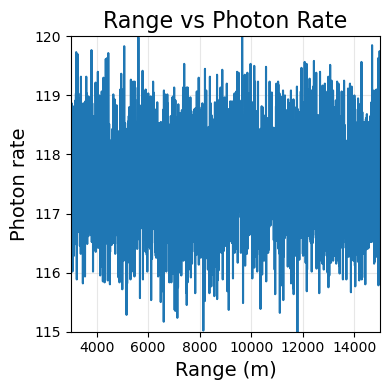

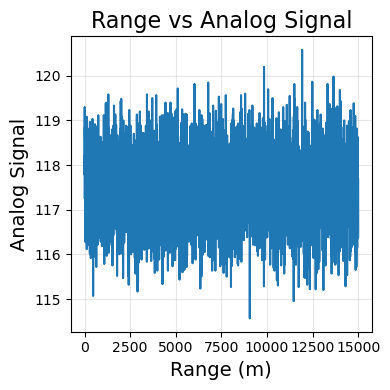

In [6]:
def plot_xy(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    xlim=None,          # ← new
    ylim=None,          # ← optional but useful
    outfile=None,
    dpi=300,
):
    # auto labels if not provided
    if title is None:
        title = f"{ycol} vs {xcol}"
    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    plt.figure(figsize=figsize)
    plt.plot(df[xcol], df[ycol])

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)

    # apply limits if provided
    if xlim is not None:
        plt.xlim(xlim)

    if ylim is not None:
        plt.ylim(ylim)

    plt.xscale(xscale)
    plt.yscale(yscale)

    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()

#plot PhotonRate vs Range
plot_xy(
    dfs["df_signal_10_40"],
    xcol="range_m",
    ycol="photon_counting",
    xlim=(3000,15000),
    ylim=(115,120),
    yscale="linear",
    title="Range vs Photon Rate",
    xlabel="Range (m)",
    ylabel="Photon rate",
    outfile="RawFilePicforExample/Prototype/range_vs_photon_rate.png",
)
plot_xy(
    dfs["df_bg_10_42"],
    xcol="range_m",
    ycol="photon_counting",
    yscale="linear",
    title="Range vs Analog Signal",
    xlabel="Range (m)",
    ylabel="Analog Signal",
    outfile="RawFilePicforExample/Prototype/range_vs_Analog_Signal.png",
)

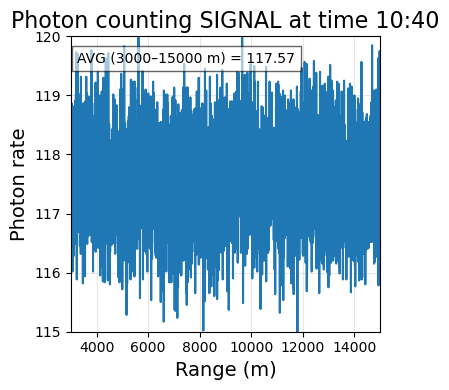

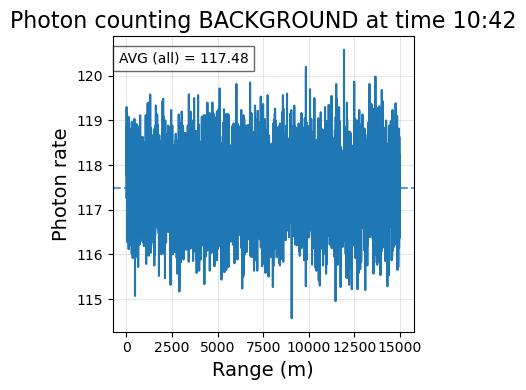

117.476353

In [15]:
import re
import matplotlib.pyplot as plt

def plot_xy_avg(
    df,
    xcol,
    ycol,
    *,
    df_name=None,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4,4),
    xlim=None,
    ylim=None,
    show_avg=True,
    outfile=None,
    dpi=300,
):

    data_type = None
    time_tag = None

    # --- detect signal/bg and time from dataframe name ---
    if df_name is not None:

        if "signal" in df_name:
            data_type = "signal"

        elif "bg" in df_name:
            data_type = "background"

        m = re.search(r"(\d{2})_(\d{2})", df_name)
        if m:
            time_tag = f"{m.group(1)}:{m.group(2)}"

    # --- auto title ---
    if ycol == "photon_counting" and time_tag is not None:

        if data_type == "signal":
            title = f"Photon counting SIGNAL at time {time_tag}"

        elif data_type == "background":
            title = f"Photon counting BACKGROUND at time {time_tag}"

        else:
            title = f"Photon counting signal at time {time_tag}"

    if title is None:
        title = f"{ycol} vs {xcol}"

    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(df[xcol], df[ycol])

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=16)

    # --- average ---
    if show_avg:

        if xlim is None:
            avg_val = df[ycol].mean()
            label = f"AVG (all) = {avg_val:.2f}"
        else:
            mask = (df[xcol] >= xlim[0]) & (df[xcol] <= xlim[1])
            avg_val = df.loc[mask, ycol].mean()
            label = f"AVG ({xlim[0]}–{xlim[1]} m) = {avg_val:.2f}"

        ax.axhline(avg_val, linestyle="--", alpha=0.7)

        ax.text(
            0.02,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.6),
        )

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_xscale(xscale)
    ax.set_yscale(yscale)

    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    # --- auto filename from title ---
    if outfile is None:
        safe_title = re.sub(r"[^\w\-_. ]", "", title).replace(" ", "_")
        outfile = f"{safe_title}.png"

    plt.savefig(outfile, dpi=dpi)

    plt.show()

    return avg_val
    
plot_xy_avg(
    dfs["df_signal_10_40"],
    xcol="range_m",
    ycol="photon_counting",
    df_name="df_signal_10_40",
    xlim=(3000,15000),
    ylim=(115,120),
    yscale="linear",
    xlabel="Range (m)",
    ylabel="Photon rate",
)

plot_xy_avg(
    dfs["df_bg_10_42"],
    xcol="range_m",
    ycol="photon_counting",
    df_name="df_bg_10_42",
    yscale="linear",
    xlabel="Range (m)",
    ylabel="Photon rate",
)

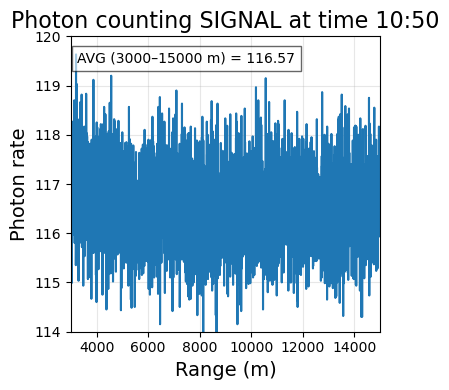

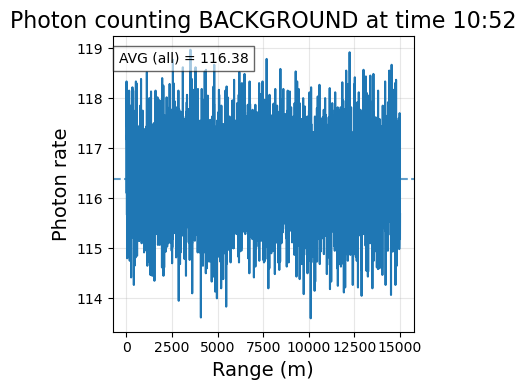

116.3755085

In [72]:
plot_xy_avg(
    dfs["df_signal_10_50"],
    xcol="range_m",
    ycol="photon_counting",
    df_name="df_signal_10_50",
    xlim=(3000,15000),
    ylim=(114,120),
    yscale="linear",
    xlabel="Range (m)",
    ylabel="Photon rate",
)

plot_xy_avg(
    dfs["df_bg_10_52"],
    xcol="range_m",
    ycol="photon_counting",
    df_name="df_bg_10_52",
    yscale="linear",
    xlabel="Range (m)",
    ylabel="Photon rate",
)

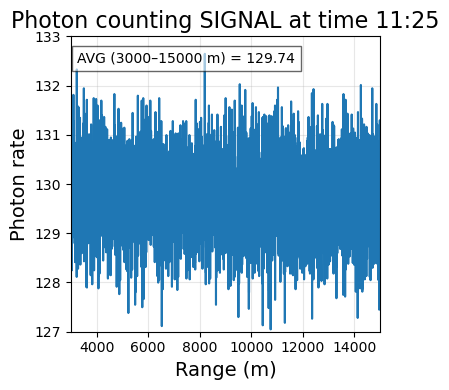

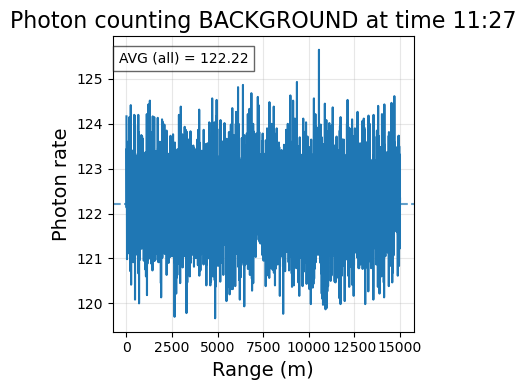

122.22201274999999

In [86]:
plot_xy_avg(
    dfs["df_signal_11_25"],
    xcol="range_m",
    ycol="photon_counting",
    df_name="df_signal_11_25",
    xlim=(3000,15000),
    ylim=(127,133),
    yscale="linear",
    xlabel="Range (m)",
    ylabel="Photon rate",
)

plot_xy_avg(
    dfs["df_bg_11_27"],
    xcol="range_m",
    ycol="photon_counting",
    df_name="df_bg_11_27",
    yscale="linear",
    xlabel="Range (m)",
    ylabel="Photon rate",
)

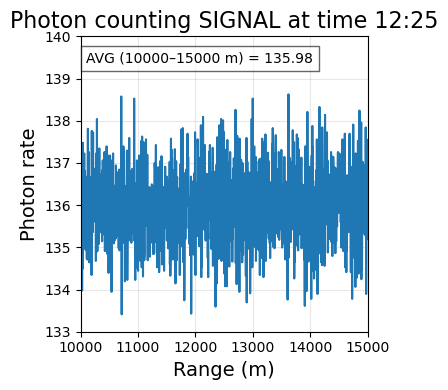

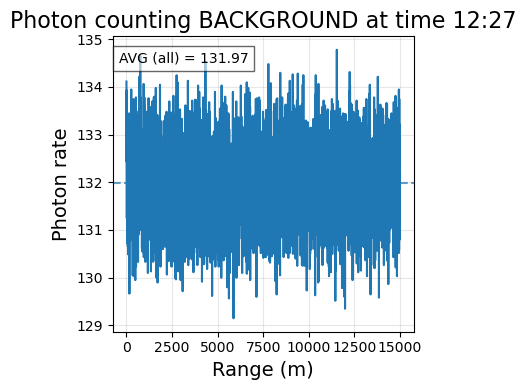

131.97286275

In [96]:
plot_xy_avg(
    dfs["df_signal_12_25"],
    xcol="range_m",
    ycol="photon_counting",
    df_name="df_signal_12_25",
    xlim=(10000,15000),
    ylim=(133,140),
    yscale="linear",
    xlabel="Range (m)",
    ylabel="Photon rate",
)

plot_xy_avg(
    dfs["df_bg_12_27"],
    xcol="range_m",
    ycol="photon_counting",
    df_name="df_bg_12_27",
    yscale="linear",
    xlabel="Range (m)",
    ylabel="Photon rate",
)

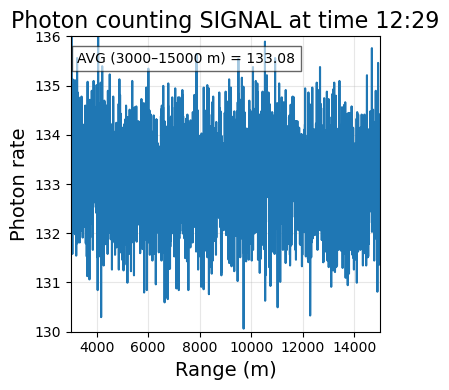

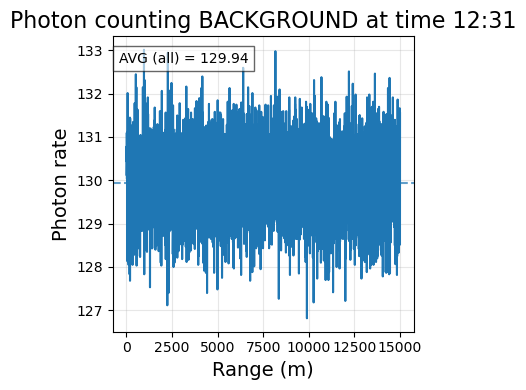

129.94415775

In [102]:
plot_xy_avg(
    dfs["df_signal_12_29"],
    xcol="range_m",
    ycol="photon_counting",
    df_name="df_signal_12_29",
    xlim=(3000,15000),
    ylim=(130,136),
    yscale="linear",
    xlabel="Range (m)",
    ylabel="Photon rate",
)

plot_xy_avg(
    dfs["df_bg_12_31"],
    xcol="range_m",
    ycol="photon_counting",
    df_name="df_bg_12_31",
    yscale="linear",
    xlabel="Range (m)",
    ylabel="Photon rate",
)

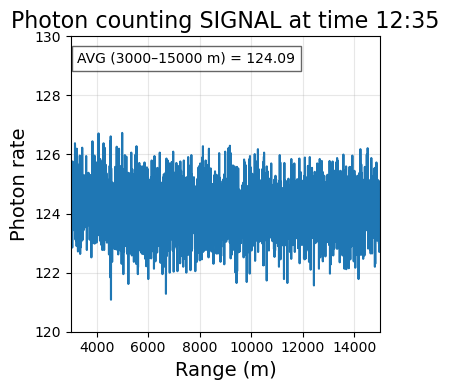

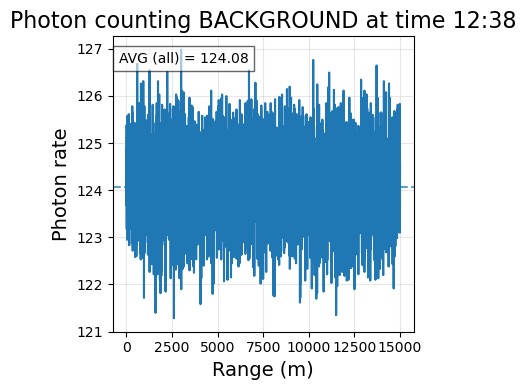

124.07597875

In [106]:
plot_xy_avg(
    dfs["df_signal_12_35"],
    xcol="range_m",
    ycol="photon_counting",
    df_name="df_signal_12_35",
    xlim=(3000,15000),
    ylim=(120,130),
    yscale="linear",
    xlabel="Range (m)",
    ylabel="Photon rate",
)

plot_xy_avg(
    dfs["df_bg_12_38"],
    xcol="range_m",
    ycol="photon_counting",
    df_name="df_bg_12_38",
    yscale="linear",
    xlabel="Range (m)",
    ylabel="Photon rate",
)

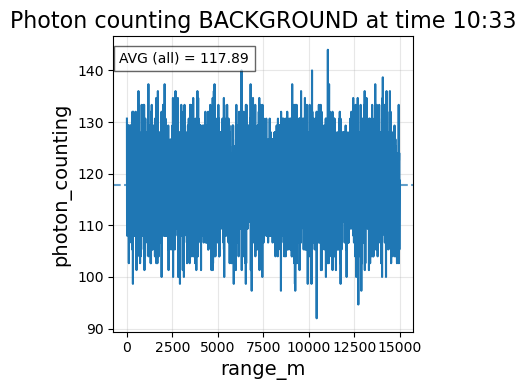

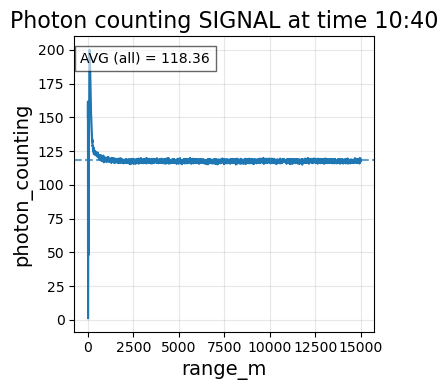

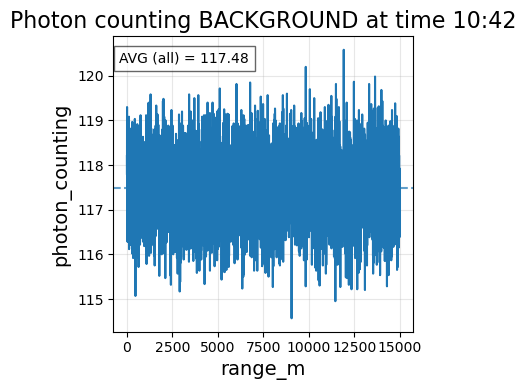

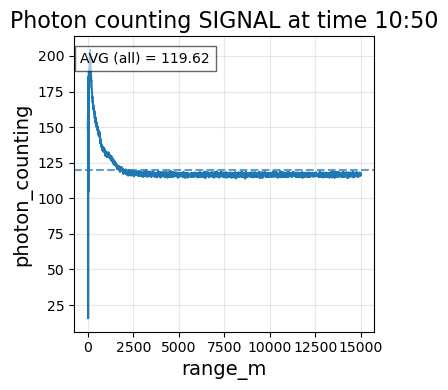

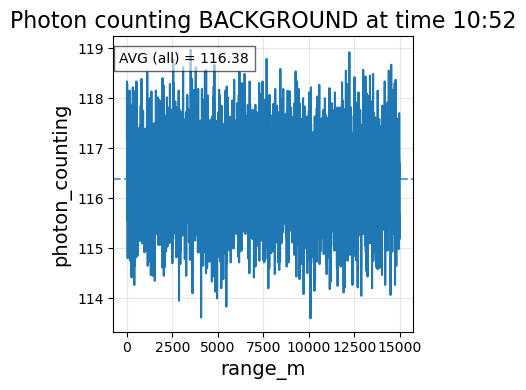

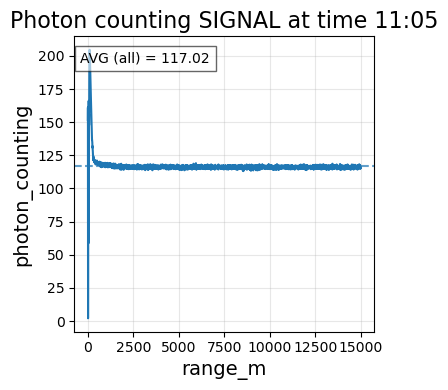

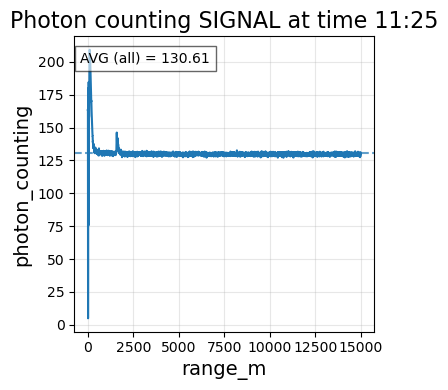

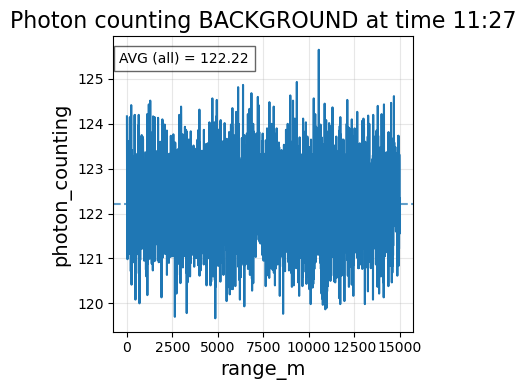

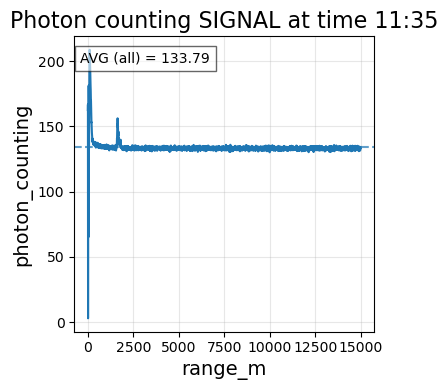

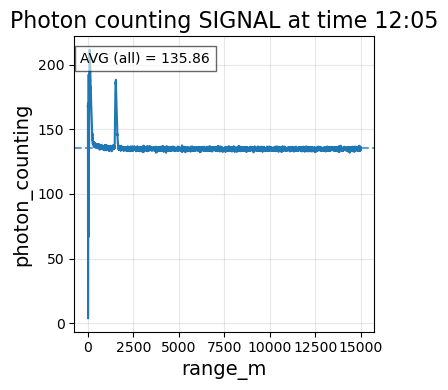

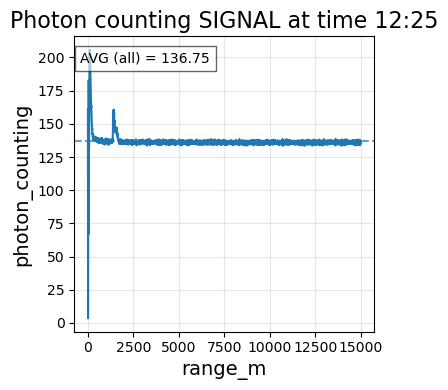

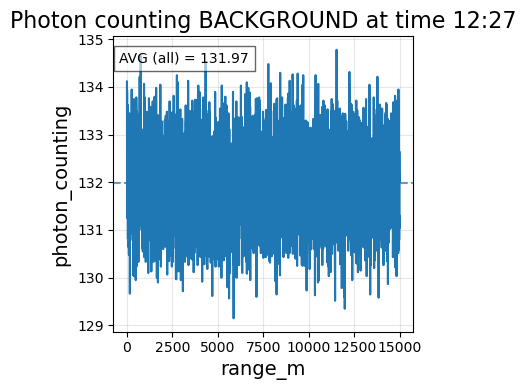

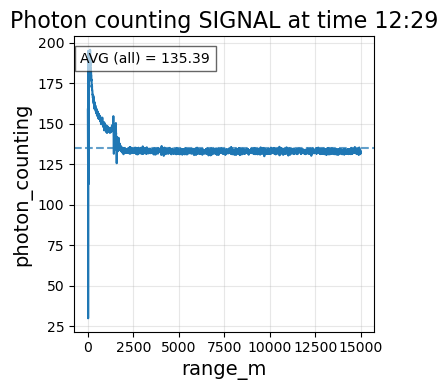

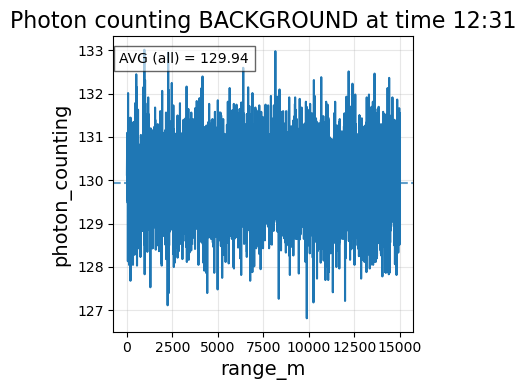

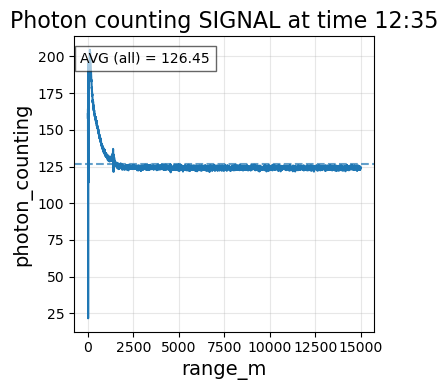

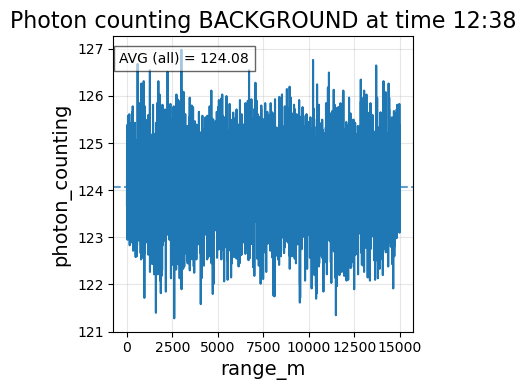

KeyError: 'range_m'

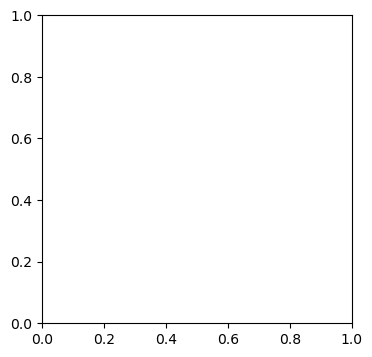

In [62]:
import re
import matplotlib.pyplot as plt

def plot_xy_avg(
    df,
    xcol,
    ycol,
    *,
    df_name=None,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4,4),
    xlim=None,
    ylim=None,
    show_avg=True,
    outfile=None,
    dpi=300,
):

    data_type = None
    time_tag = None

    # --- detect signal/bg and time from dataframe name ---
    if df_name is not None:

        if "signal" in df_name:
            data_type = "signal"

        elif "bg" in df_name:
            data_type = "background"

        m = re.search(r"(\d{2})_(\d{2})", df_name)
        if m:
            time_tag = f"{m.group(1)}:{m.group(2)}"

    # --- auto title ---
    if ycol == "photon_counting" and time_tag is not None:

        if data_type == "signal":
            title = f"Photon counting SIGNAL at time {time_tag}"

        elif data_type == "background":
            title = f"Photon counting BACKGROUND at time {time_tag}"

        else:
            title = f"Photon counting signal at time {time_tag}"

    if title is None:
        title = f"{ycol} vs {xcol}"

    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(df[xcol], df[ycol])

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=16)

    # --- average ---
    if show_avg:

        if xlim is None:
            avg_val = df[ycol].mean()
            label = f"AVG (all) = {avg_val:.2f}"
        else:
            mask = (df[xcol] >= xlim[0]) & (df[xcol] <= xlim[1])
            avg_val = df.loc[mask, ycol].mean()
            label = f"AVG ({xlim[0]}–{xlim[1]} m) = {avg_val:.2f}"

        ax.axhline(avg_val, linestyle="--", alpha=0.7)

        ax.text(
            0.02,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.6),
        )

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_xscale(xscale)
    ax.set_yscale(yscale)

    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    # --- auto filename from title ---
    if outfile is None:
        safe_title = re.sub(r"[^\w\-_. ]", "", title).replace(" ", "_")
        outfile = f"{safe_title}.png"

    plt.savefig(outfile, dpi=dpi)

    plt.show()

    return avg_val
    
for name, df in dfs.items():

    plot_xy(
        df,
        xcol="range_m",
        ycol="photon_counting",
        df_name=name
    )

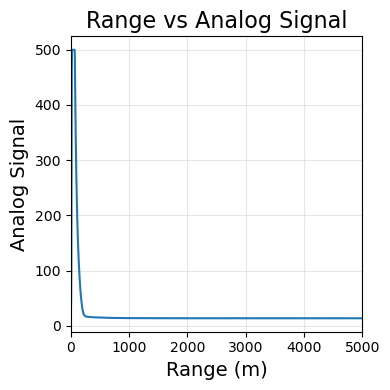

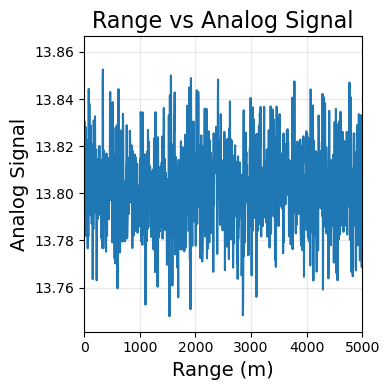

In [33]:

#plot PhotonRate vs Range
plot_xy(
    dfs["df_signal_10_40"],
    xcol="range_m",
    ycol="analog",
    yscale="linear",
    title="Range vs Analog Signal",
    xlabel="Range (m)",
    ylabel="Analog Signal",
    outfile="RawFilePicforExample/Prototype/range_vs_Analog_Signal.png",
)
plot_xy(
    dfs["df_bg_10_42"],
    xcol="range_m",
    ycol="analog",
    yscale="linear",
    title="Range vs Analog Signal",
    xlabel="Range (m)",
    ylabel="Analog Signal",
    outfile="RawFilePicforExample/Prototype/range_vs_Analog_Signal.png",
)